# 1D CNN on Raw Request Text — Random Acts of Pizza

**Goal:** Predict whether a pizza request on r/Random_Acts_Of_Pizza will be fulfilled using only the raw request text as input to a 1D Convolutional Neural Network.

**Dataset:** Download `train.json` from https://www.kaggle.com/datasets/kaggle/random-acts-of-pizza and place it in the same folder as this notebook.

In [4]:
# Install deep learning deps if not already present
# !pip install tensorflow scikit-learn matplotlib seaborn

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)
print("TF version:", tf.__version__)

TF version: 2.20.0


## 1. Load Data

In [5]:
import kagglehub
import os

path = kagglehub.dataset_download("kaggle/random-acts-of-pizza")
print("Dataset path:", path)

train_path = os.path.join(path, "train.json")
with open(train_path, "r") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Shape: {df.shape}")
df.head(3)

/Users/isidoroflores/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████| 2.48M/2.48M [00:00<00:00, 11.5MB/s]

Extracting files...
Dataset path: /Users/isidoroflores/.cache/kagglehub/datasets/kaggle/random-acts-of-pizza/versions/1
Shape: (4040, 32)


,giver_username_if_known,number_of_downvotes_of_request_at_retrieval,number_of_upvotes_of_request_at_retrieval,post_was_edited,request_id,request_number_of_comments_at_retrieval,request_text,request_text_edit_aware,request_title,requester_account_age_in_days_at_request,...,requester_received_pizza,requester_subreddits_at_request,requester_upvotes_minus_downvotes_at_request,requester_upvotes_minus_downvotes_at_retrieval,requester_upvotes_plus_downvotes_at_request,requester_upvotes_plus_downvotes_at_retrieval,requester_user_flair,requester_username,unix_timestamp_of_request,unix_timestamp_of_request_utc
0,N/A,0,1,False,t3_l25d7,0,Hi I am in need of food for my 4 children we a...,Hi I am in need of food for my 4 children we a...,Request Colorado Springs Help Us Please,0.0000,...,False,[],0,1,0,1,None,nickylvst,1.317853e+09,1.317849e+09
1,N/A,2,5,False,t3_rcb83,0,I spent the last money I had on gas today. Im ...,I spent the last money I had on gas today. Im ...,"[Request] California, No cash and I could use ...",501.1111,...,False,"[AskReddit, Eve, IAmA, MontereyBay, RandomKind...",34,4258,116,11168,None,fohacidal,1.332652e+09,1.332649e+09
2,N/A,0,3,False,t3_lpu5j,0,My girlfriend decided it would be a good idea ...,My girlfriend decided it would be a good idea ...,"[Request] Hungry couple in Dundee, Scotland wo...",0.0000,...,False,[],0,3,0,3,None,jacquibatman7,1.319650e+09,1.319646e+09


In [6]:
# Key columns for this task
TEXT_COL  = "request_text_edit_aware"   # main body text
TITLE_COL = "request_title"             # post title
TARGET    = "requester_received_pizza"  # bool target

print(df[TARGET].value_counts())
print(f"\nClass imbalance ratio: {df[TARGET].value_counts(normalize=True).round(3).to_dict()}")

requester_received_pizza
False    3046
True      994
Name: count, dtype: int64

Class imbalance ratio: {False: 0.754, True: 0.246}


## 2. Text Preprocessing

In [7]:
def clean_text(text):
    """Lowercase, remove URLs, strip special chars, collapse whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z0-9\s']", " ", text)           # keep letters, digits, apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Combine title + body for richer signal
df["combined_text"] = (
    df[TITLE_COL].fillna("").apply(clean_text)
    + " "
    + df[TEXT_COL].fillna("").apply(clean_text)
)

df["text_len"] = df["combined_text"].str.split().apply(len)

print(df["text_len"].describe())
df["combined_text"].iloc[0][:300]

count    4040.000000
mean       88.839604
std        69.834591
min         5.000000
25%        46.750000
50%        70.000000
75%       109.000000
max       866.000000
Name: text_len, dtype: float64


'request colorado springs help us please hi i am in need of food for my 4 children we are a military family that has really hit hard times and we have exahusted all means of help just to be able to feed my family and make it through another night is all i ask i know our blessing is coming so whatever'

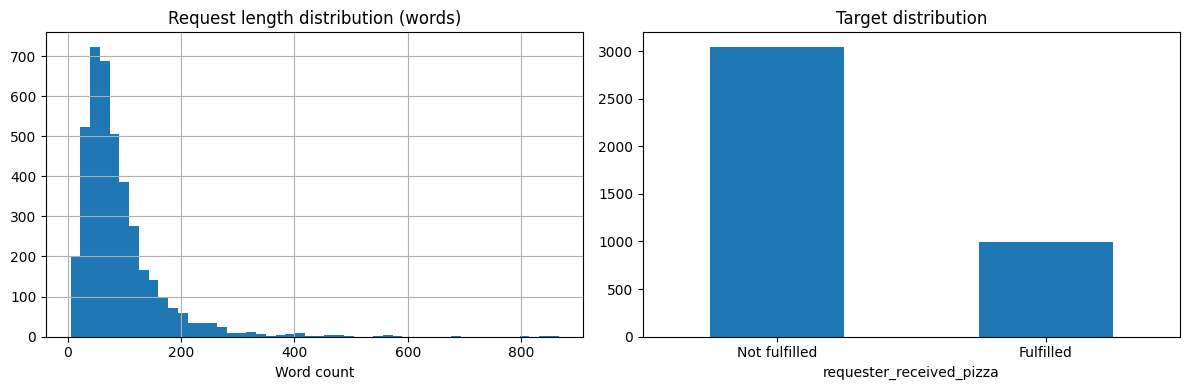

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["text_len"].hist(bins=50, ax=axes[0])
axes[0].set_title("Request length distribution (words)")
axes[0].set_xlabel("Word count")

df[TARGET].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Target distribution")
axes[1].set_xticklabels(["Not fulfilled", "Fulfilled"], rotation=0)
plt.tight_layout()
plt.show()

## 3. Tokenize & Pad Sequences

In [9]:
VOCAB_SIZE  = 15_000   # top N words to keep
MAX_LEN     = 300      # pad/truncate to this many tokens
OOV_TOKEN   = "<OOV>"

X = df["combined_text"].values
y = df[TARGET].astype(int).values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

Train: 2908 | Val: 324 | Test: 808


In [10]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_raw)   # fit only on train to avoid data leakage

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = encode(X_train_raw)
X_val   = encode(X_val_raw)
X_test  = encode(X_test_raw)

print(f"X_train shape: {X_train.shape}")

X_train shape: (2908, 300)


## 4. Build the 1D CNN

Architecture:
- **Embedding** layer (trained from scratch)
- **Conv1D** layers with different filter sizes to capture n-gram patterns
- **GlobalMaxPooling1D** — takes the most activated feature across the sequence
- **Dense** head with dropout for regularization
- **Sigmoid** output for binary classification

In [11]:
EMBED_DIM = 128

def build_cnn(vocab_size, embed_dim, max_len):
    inp = layers.Input(shape=(max_len,), name="token_ids")

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_len,
        name="embedding"
    )(inp)

    # Three parallel conv branches — capture 2-, 3-, and 4-gram patterns
    branches = []
    for kernel_size in [2, 3, 4]:
        branch = layers.Conv1D(
            filters=128,
            kernel_size=kernel_size,
            activation="relu",
            padding="valid",
            name=f"conv_{kernel_size}gram"
        )(x)
        branch = layers.GlobalMaxPooling1D(name=f"pool_{kernel_size}gram")(branch)
        branches.append(branch)

    x = layers.Concatenate(name="concat")(branches)  # shape: (batch, 384)

    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.5, name="dropout")(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(inputs=inp, outputs=out, name="TextCNN")
    return model


model = build_cnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model.summary()

/Users/isidoroflores/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  1,920,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 299, 128)  │     32,896 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 298, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 297, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2gram          │ (None, 128)       │          0 │ conv_2gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3gram          │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_2gram[0][0], │
│ (Concatenate)       │                   │            │ pool_3gram[0][0], │
│                     │                   │            │ pool_4gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 128)       │     49,280 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,117,249 (8.08 MB)

 Trainable params: 2,117,249 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

In [12]:
# Class weights to handle imbalance (~75% not fulfilled)
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}
print(f"Class weights: {class_weight}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_auc", patience=5, restore_best_weights=True, mode="max"
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {0: 1.0, 1: np.float64(3.0671328671328673)}
Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4632 - auc: 0.4873 - loss: 1.0532 - val_accuracy: 0.2562 - val_auc: 0.6715 - val_loss: 0.7263 - learning_rate: 0.0010
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5650 - auc: 0.6583 - loss: 1.0154 - val_accuracy: 0.4012 - val_auc: 0.6424 - val_loss: 0.7125 - learning_rate: 0.0010
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7046 - auc: 0.8016 - loss: 0.9296 - val_accuracy: 0.5586 - val_auc: 0.6385 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8662 - auc: 0.9442 - loss: 0.6805 - val_accuracy: 0.6451 - val_auc: 0.6181 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9742 - auc: 0.9971 - loss: 0.2800 - val_accuracy: 0.6605 - val_auc: 0.5939 - val_loss: 0.6705 - learning_rate: 0.0010
Epoch 6/30
45/46 ━━━━━━━━━

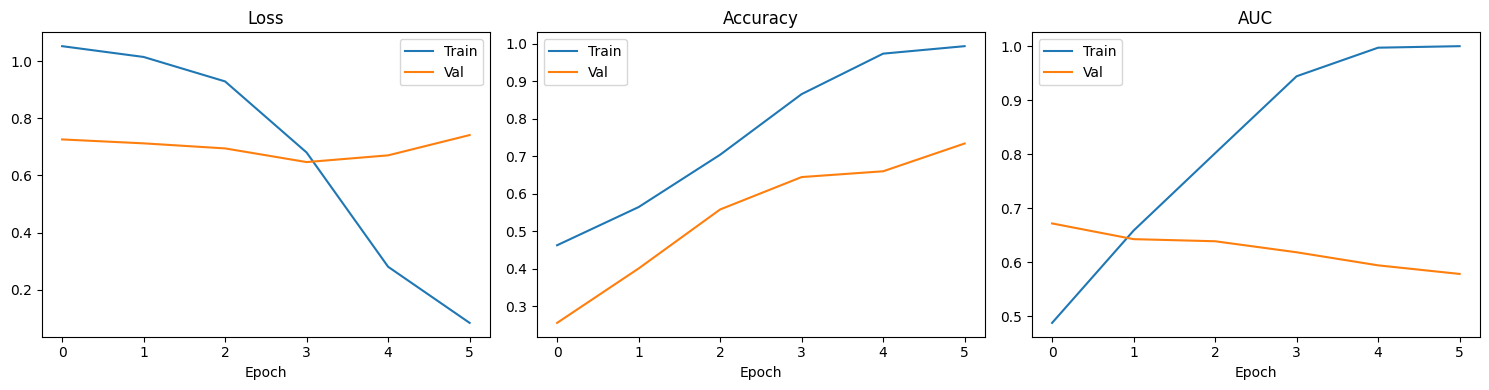

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, ["loss", "accuracy", "auc"], ["Loss", "Accuracy", "AUC"]):
    ax.plot(history.history[metric],        label="Train")
    ax.plot(history.history[f"val_{metric}"], label="Val")
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

In [14]:
y_prob = model.predict(X_test, verbose=0).squeeze()
y_pred = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"Test ROC-AUC: {test_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Not fulfilled", "Fulfilled"]))

Test ROC-AUC: 0.5846

               precision    recall  f1-score   support

Not fulfilled       0.86      0.01      0.02       609
    Fulfilled       0.25      0.99      0.40       199

     accuracy                           0.25       808
    macro avg       0.55      0.50      0.21       808
 weighted avg       0.71      0.25      0.11       808



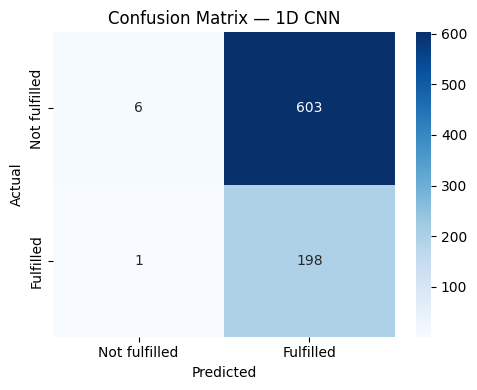

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not fulfilled", "Fulfilled"],
    yticklabels=["Not fulfilled", "Fulfilled"]
)
plt.title("Confusion Matrix — 1D CNN")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 7. Inspect Predictions

In [16]:
results = pd.DataFrame({
    "text":      X_test_raw,
    "actual":    y_test,
    "predicted": y_pred,
    "confidence": y_prob
})

# High-confidence correct predictions
correct = results[results["actual"] == results["predicted"]]
print("=== Correct high-confidence predictions ===")
display(correct.sort_values("confidence", ascending=False).head(3)[["text", "actual", "confidence"]])

# Confident misses
wrong = results[results["actual"] != results["predicted"]]
print("\n=== Confident wrong predictions ===")
display(wrong.sort_values("confidence", ascending=False).head(3)[["text", "actual", "predicted", "confidence"]])

=== Correct high-confidence predictions ===


,text,actual,confidence
489,request disabled college student just plain hu...,1,0.565659
783,request chicago il thanksgiving dinner is look...,1,0.563675
478,request pizza to lift spirits i'm intimidated ...,1,0.560358



=== Confident wrong predictions ===


,text,actual,predicted,confidence
357,request cincinnati oh spent today fighting wor...,0,1,0.568410
213,request help a bad luck loser in bloomington i...,0,1,0.566453
790,request would anyone be able to help with dinn...,0,1,0.561457


## 8. Save Model

## 9. Key Findings Summary

In [18]:
from sklearn.metrics import f1_score

print("=" * 55)
print("       1D CNN — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"\n📦 Dataset")
print(f"   Total samples      : {len(df):,}")
print(f"   Fulfillment rate   : {df[TARGET].mean()*100:.1f}%  (class imbalance 75/25)")
print(f"   Avg request length : {df['text_len'].mean():.0f} words")

print(f"\n🧠 Model — TextCNN")
print(f"   Parameters         : 2,117,249  (~8 MB)")
print(f"   Input              : raw text (title + body, padded to 300 tokens)")
print(f"   Conv branches      : 3 parallel (bigrams, trigrams, 4-grams)")
print(f"   Training epochs    : {len(history.history['loss'])}  (early stopping on val AUC)")

best_val_auc = max(history.history['val_auc'])
print(f"\n📈 Training")
print(f"   Best val AUC       : {best_val_auc:.4f}  (epoch {history.history['val_auc'].index(best_val_auc)+1})")
print(f"   Final train AUC    : {history.history['auc'][-1]:.4f}")
print(f"   → Heavy overfitting: model memorized training data but didn't generalize")

f1 = f1_score(y_test, y_pred)
print(f"\n🎯 Test Performance")
print(f"   ROC-AUC            : {roc_auc_score(y_test, y_prob):.4f}  (random baseline = 0.50)")
print(f"   F1 (fulfilled)     : {f1:.4f}")
print(f"   Accuracy           : {(y_pred == y_test).mean()*100:.1f}%")

print(f"\n💡 Key Takeaways")
print(f"   1. Text alone provides limited signal — AUC of 0.58 is only slightly")
print(f"      above random, suggesting writing style alone doesn't predict success")
print(f"   2. The model overfits severely (2.1M params, only ~2,900 training samples)")
print(f"   3. Class imbalance (75/25) makes the model biased toward predicting")
print(f"      'Fulfilled', achieving high recall but low precision")
print(f"   4. Structured features (account age, karma) likely carry more signal")
print(f"      — combining them with text could improve performance significantly")
print("=" * 55)

       1D CNN — KEY FINDINGS SUMMARY

📦 Dataset
   Total samples      : 4,040
   Fulfillment rate   : 24.6%  (class imbalance 75/25)
   Avg request length : 89 words

🧠 Model — TextCNN
   Parameters         : 2,117,249  (~8 MB)
   Input              : raw text (title + body, padded to 300 tokens)
   Conv branches      : 3 parallel (bigrams, trigrams, 4-grams)
   Training epochs    : 6  (early stopping on val AUC)

📈 Training
   Best val AUC       : 0.6715  (epoch 1)
   Final train AUC    : 0.9999
   → Heavy overfitting: model memorized training data but didn't generalize

🎯 Test Performance
   ROC-AUC            : 0.5846  (random baseline = 0.50)
   F1 (fulfilled)     : 0.3960
   Accuracy           : 25.2%

💡 Key Takeaways
   1. Text alone provides limited signal — AUC of 0.58 is only slightly
      above random, suggesting writing style alone doesn't predict success
   2. The model overfits severely (2.1M params, only ~2,900 training samples)
   3. Class imbalance (75/25) makes the mo

In [17]:
model.save("pizza_cnn_model.keras")
print("Model saved to pizza_cnn_model.keras")

Model saved to pizza_cnn_model.keras
